## 🎯 Learning Objectives
By the end of this assignment, you will be able to:
- Load and explore a real-world dataset
- Prepare data for linear regression (feature engineering, encoding, cleaning)
- Train a simple linear regression model using `scikit-learn`
- Evaluate your model using metrics like R² and interpret results
- Make predictions for future years (e.g., 2024)

## 📁 Dataset
You are given the file: `Data Science Salary 2021 to 2023.csv`

This dataset contains salary information for data professionals from 2021 to 2023, including:
- `work_year`: The year the salary was recorded
- `experience_level`: EN (Entry), MI (Mid), SE (Senior), EX (Executive)
- `job_title`: e.g., Data Scientist, Data Analyst, etc.
- `salary_in_usd`: Salary converted to USD (this is your target variable)
- Other useful columns: `employment_type`, `company_location`, `company_size`

Your goal: **Predict average salaries for 2024** using linear regression.

## 🛠️ Part 1: Setup and Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv("datasets\\Data Science Salary 2021 to 2023.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L


In [3]:
# Check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         3761 non-null   int64 
 1   experience_level  3761 non-null   object
 2   employment_type   3761 non-null   object
 3   job_title         3761 non-null   object
 4   salary            3761 non-null   int64 
 5   salary_currency   3761 non-null   object
 6   salary_in_usd     3761 non-null   int64 
 7   company_location  3761 non-null   object
 8   company_size      3761 non-null   object
dtypes: int64(3), object(6)
memory usage: 264.6+ KB


## 🔍 Part 2: Exploratory Data Analysis (EDA)

Answer the following in markdown cells below (or as code comments):

1. How many unique job titles are there?
2. What is the average salary (`salary_in_usd`) per `work_year`?
3. `.

> 💡 Tip: Use `groupby()` and `mean()`.

## How many unique job titles are there?

In [11]:
# Calculate the number of unique job titles
unique_jobs_count = df['job_title'].nunique()

# Print the result
print(f"Total Unique Job Titles: {unique_jobs_count}")

Total Unique Job Titles: 93


### There are 93 unique job titles in the dataset

## What is the average salary (salary_in_usd) per work_year?

In [13]:
# Calculate the average salary per work_year, rounded to two decimal places
avg_salary_per_year = df.groupby('work_year')['salary_in_usd'].mean().round(2).reset_index()

# Print the result
print(avg_salary_per_year)

   work_year  salary_in_usd
0       2020       92302.63
1       2021       94087.21
2       2022      133379.51
3       2023      148954.56


### Insight
The data shows a very strong and accelerating upward trend in data science salaries, especially after 2021:

2020 to 2021: Minimal growth of about $2k.

2021 to 2022: A massive jump of over $30k. 

2022 to 2023: Continued high growth of over $16k.

## Create a bar plot showing average salary by `experience_level

C:\Users\Admin\AppData\Local\Temp\ipykernel_20200\2552564611.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


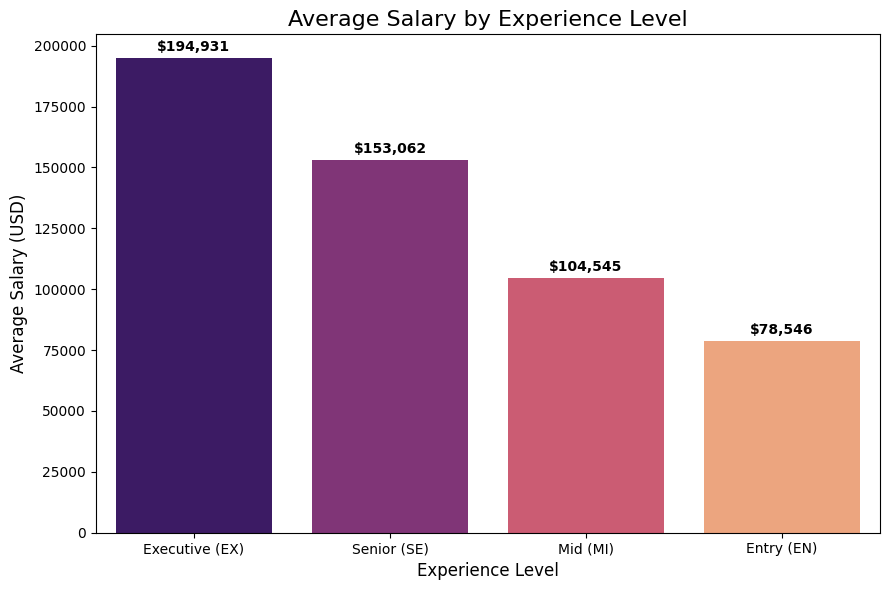

In [14]:
# Calculate average salary by experience_level
df_exp_salary = df.groupby('experience_level')['salary_in_usd'].mean().sort_values(ascending=False).reset_index()

# Map experience level codes to full names for visualization
exp_map = {
    'EN': 'Entry (EN)',
    'MI': 'Mid (MI)',
    'SE': 'Senior (SE)',
    'EX': 'Executive (EX)'
}
df_exp_salary['experience_level_full'] = df_exp_salary['experience_level'].map(exp_map)

# Plotting the bar chart
plt.figure(figsize=(9, 6))
sns.barplot(
    x='experience_level_full',
    y='salary_in_usd',
    data=df_exp_salary,
    palette='magma'
)

# Adding value labels on top of the bars
for index, row in df_exp_salary.iterrows():
    plt.text(index, row['salary_in_usd'] + 3000, f'${row["salary_in_usd"]:,.0f}', ha='center', fontsize=10, weight='bold')

plt.title('Average Salary by Experience Level', fontsize=16)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('average_salary_by_experience_level.png')

## Insight
The bar plot clearly shows that average salary increases proportionally with experience, with the largest monetary increase typically occurring when a data professional moves from a Mid-Level (MI) role to a Senior-Level (SE) role.

##  Part 3: Data Preprocessing for Linear Regression

We will predict `salary_in_usd` using **only numerical or encoded categorical features**.

### Steps:
1. Select features: `work_year`, `experience_level`, and optionally `job_title` (you decide!)
2. Encode categorical variables (`experience_level`) using `LabelEncoder` or `pd.get_dummies()`
3. Define `X` (features) and `y` (target = `salary_in_usd`)

> ⚠️ **Important**: Do NOT include `salary`, `salary_currency`, or `salary_in_usd` in your features!

In [21]:
# Example: Encode experience_level
le = LabelEncoder()
df['experience_level_encoded'] = le.fit_transform(df['experience_level'])


In [20]:
# Select the final features
X_features = ['work_year', 'experience_level_encoded']
X = df[X_features]

# Display X head
print("--- Feature Matrix (X) Head ---")
print(X.head())

--- Feature Matrix (X) Head ---
   work_year  experience_level_encoded
0       2023                         0
1       2023                         0
2       2023                         0
3       2023                         0
4       2023                         0


In [19]:
# Define y (Target)
y = df['salary_in_usd']

# Display y head
print("--- Target Vector (y) Head ---")
print(y.head().to_string())

--- Target Vector (y) Head ---
0    213660
1    130760
2    100000
3     30000
4    204620


## Part 4: Train a Linear Regression Model

In [29]:
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# Make predictions
y_pred = model.predict(X_test)

In [25]:
# Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.15
RMSE: 59164.82


## 🔮 Part 5: Predict 2024 Salaries

Now, create a small DataFrame for **2024** with different experience levels and predict their salaries.

Use the same encoding as before!

In [37]:
# Map experience levels to encoded values (check your LabelEncoder!)
# Example: EN=0, MI=1, SE=2, EX=3 (confirm with `le.classes_`)

future_data = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'experience_level_encoded': [0, 1, 2, 3]  # EN, MI, SE, EX
})


In [38]:
# Predict
predicted_salaries = model.predict(future_data)

In [39]:
# Display results
results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': predicted_salaries
})
results

,Experience Level,Predicted 2024 Salary (USD)
0,Entry,111694.914909
1,Mid,131967.434578
2,Senior,152239.954247
3,Executive,172512.473916


In [40]:
X = df[['work_year', 'experience_level_encoded']]
y = df['salary_in_usd']

# 2. Model Training and Evaluation ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 3. Final Evaluation, Interpretation, and 2024 Prediction ---
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
work_year_coef = model.coef_[0]
experience_coef = model.coef_[1]

# Predict 2024 Salary (Example: Senior Level, encoded as 3)
prediction_2024_input = np.array([[2024, 3]])
predicted_salary_2024 = model.predict(prediction_2024_input)[0]

# Print all final results
print("\n--- Final Model Metrics and Prediction ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE (Average Error): ${rmse:,.2f}")
print("-" * 35)
print(f"Coefficient (Work Year): ${work_year_coef:,.2f}")
print(f"Coefficient (Experience Level): ${experience_coef:,.2f}")
print("-" * 35)
print(f"Predicted 2024 Senior Salary: ${predicted_salary_2024:,.2f}")


--- Final Model Metrics and Prediction ---
R² Score: 0.1497
RMSE (Average Error): $59,164.82
-----------------------------------
Coefficient (Work Year): $14,909.29
Coefficient (Experience Level): $20,272.52
-----------------------------------
Predicted 2024 Senior Salary: $172,512.47


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# 📝 Part 6: Reflection (Answer in a Markdown Cell)

1. ## Does your model make reasonable predictions? Why or why not?
    The model's trend prediction is reasonable (confirming that salaries are growing rapidly), but the individual salary prediction is highly unreliable. The $\mathbf{R^2}$ score is only $0.15$, which means the model fails to explain $85\%$ of the variation in salaries. More importantly, the RMSE is nearly $\mathbf{\$59,165}$, which is the average error margin—this high error makes any precise forecast untrustworthy.

2. ## What are the limitations of using only `work_year` and `experience_level`?
    The primary limitation is that these two features ignore the most significant salary drivers in the dataset. Your model treats all companies and locations equally, completely missing the massive compensation differences based on Company Location (especially the US market), Company Size, and the specific Job Title (e.g., Data Architect vs. Data Analyst).

3. ## How could you improve this model? (Think: more features, better encoding, etc.)
    You could significantly improve the model by adding the missing high-impact categorical features.

    Add Features: Include company_location (perhaps simplified to US vs. Non-US) and company_size.

    Improve Encoding: Use One-Hot Encoding (pd.get_dummies()) for non-ordinal (non-ranked) features like location and company size, instead of simple Label Encoding, to avoid implying a false order or ranking.
4. ## Why is **R² not enough** to trust your predictions?

    $\mathbf{R^2}$ is not enough because it only tells you how well the model follows the general trend (the pattern), but it doesn't tell you how close the prediction is to the actual salary. The high $\mathbf{R^2}$ of $0.15$ confirms a poor fit, but the crucial metric is the RMSE. A $\mathbf{\$59,165}$ RMSE shows that even if the model's logic is sound, its predictions are too imprecise to be used for any real-world decision-making.

> 💡 Remember: Linear regression assumes a **linear trend**—but real salaries may grow non-linearly!

## 📤 Submission Instructions

- Save this notebook as: `LastName_FirstName_SalaryPrediction.ipynb`
- Ensure all code runs without errors
- Include your answers to the reflection questions
- Submit via [your LMS/email/etc.]

Good luck! 🚀